In [29]:
pip install pandas numpy matplotlib seaborn jupyter ta

Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd

df = pd.read_csv("../data/raw/Data/AAPL.csv")

In [31]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB


In [33]:
print(df.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [34]:
df = df.dropna()

In [35]:
df["Date"] = pd.to_datetime(df["Date"])

In [36]:
df.set_index("Date", inplace=True)

In [37]:
from ta.trend import SMAIndicator

In [38]:
sma_20 = SMAIndicator(close=df["Close"], window=20)

df["SMA_20"] = sma_20.sma_indicator()

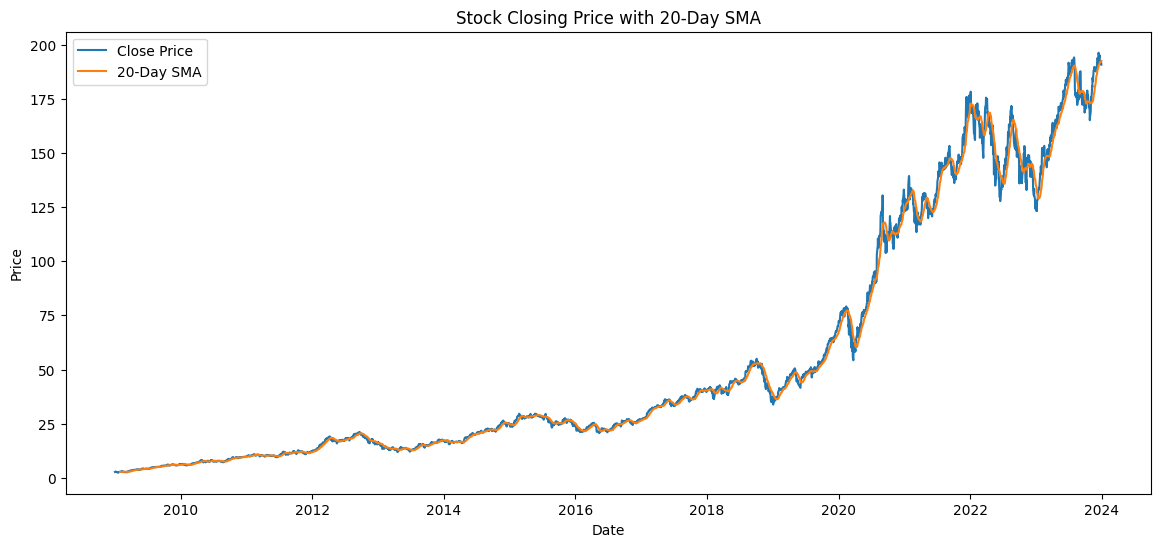

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"], label="Close Price")

plt.plot(df.index, df["SMA_20"], label="20-Day SMA")

plt.title("Stock Closing Price with 20-Day SMA")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [40]:
from ta.trend import EMAIndicator

In [41]:
ema_20 = EMAIndicator(close=df["Close"], window=20)

df["EMA_20"] = ema_20.ema_indicator()

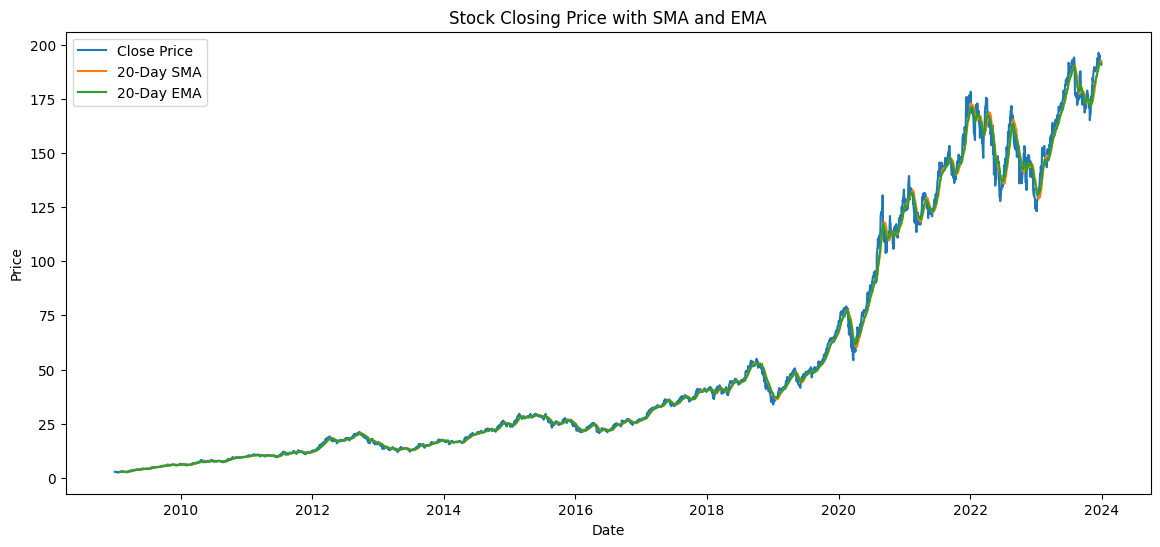

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"], label="Close Price")

plt.plot(df.index, df["SMA_20"], label="20-Day SMA")

plt.plot(df.index, df["EMA_20"], label="20-Day EMA")

plt.title("Stock Closing Price with SMA and EMA")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

The SMA and EMA indicators helped smooth short-term stock price fluctuations and made broader market trends easier to observe.

The EMA followed the stock price more closely than the SMA because it gives greater importance to recent prices. This allowed the EMA to react faster to sudden market changes.

Periods where the stock price remained above both moving averages may indicate positive market momentum, while periods below the indicators may suggest downward pressure or market correction.

In [43]:
from ta.momentum import RSIIndicator

In [44]:
rsi = RSIIndicator(close=df["Close"], window=14)

df["RSI"] = rsi.rsi()

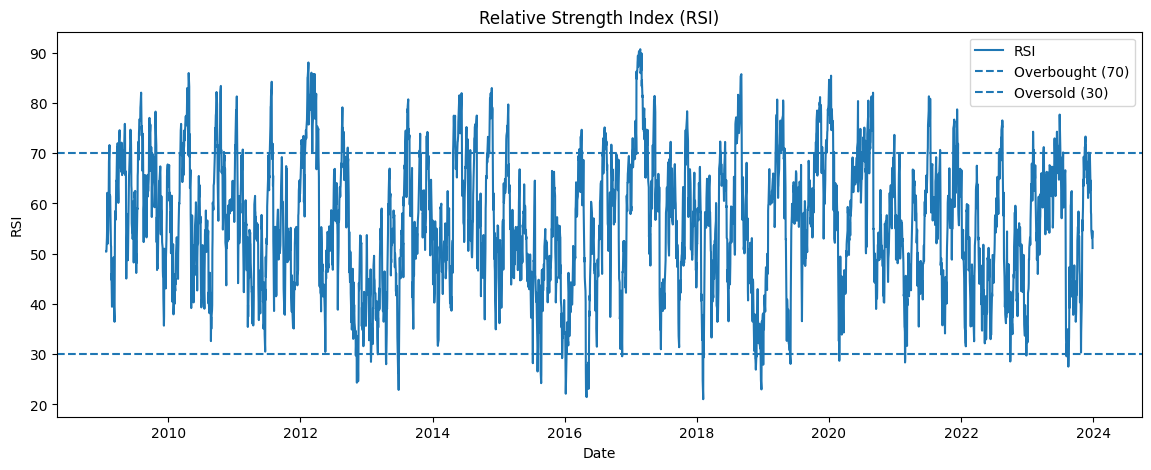

In [45]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["RSI"], label="RSI")

plt.axhline(70, linestyle='--', label='Overbought (70)')

plt.axhline(30, linestyle='--', label='Oversold (30)')

plt.title("Relative Strength Index (RSI)")

plt.xlabel("Date")

plt.ylabel("RSI")

plt.legend()

plt.show()

This visualization shows the Relative Strength Index (RSI) of the stock over time. The RSI measures market momentum and helps identify potential overbought or oversold conditions using standard threshold values of 70 and 30.

Key Findings
The RSI fluctuated frequently throughout the observed period, indicating continuous changes in market momentum.
Several periods showed RSI values rising above 70, suggesting strong buying pressure and possible overbought conditions.
There were also multiple periods where the RSI dropped close to or below 30, indicating possible oversold conditions and weaker market momentum.
Most RSI values remained between 30 and 70, suggesting that the stock generally traded within a normal momentum range for much of the period.
The repeated movement between higher and lower RSI levels reflects periods of changing investor sentiment and market volatility.
Interpretation

The RSI analysis suggests that the stock experienced multiple cycles of bullish and bearish momentum over time. Occasional spikes above the overbought threshold may indicate periods where the stock price increased rapidly, while drops near the oversold threshold may reflect temporary market weakness or corrections. Overall, the indicator highlights changing momentum patterns and helps identify periods where market conditions may have shifted significantly.

In [46]:
from ta.trend import MACD

In [47]:
macd = MACD(close=df["Close"])

df["MACD"] = macd.macd()

df["MACD_signal"] = macd.macd_signal()

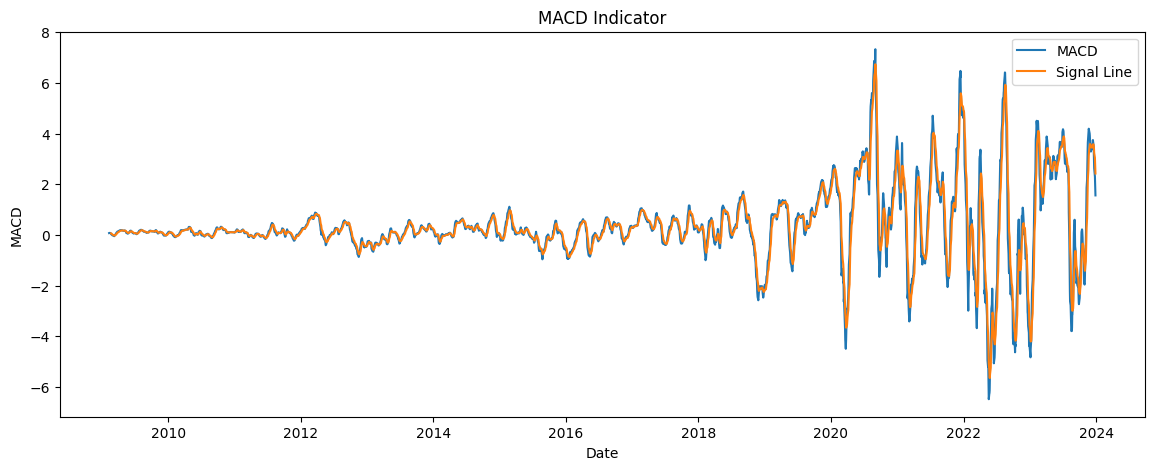

In [48]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["MACD"], label="MACD")

plt.plot(df.index, df["MACD_signal"], label="Signal Line")

plt.title("MACD Indicator")

plt.xlabel("Date")

plt.ylabel("MACD")

plt.legend()

plt.show()

This visualization presents the Moving Average Convergence Divergence (MACD) indicator alongside its signal line. The MACD is used to analyze market momentum, trend direction, and potential trend reversals by comparing short-term and long-term moving averages.

Key Findings
The MACD and signal lines moved closely together throughout the observed period, with several crossover points indicating changes in market momentum.
Periods where the MACD line crossed above the signal line may suggest bullish momentum and possible upward price movement.
Periods where the MACD line crossed below the signal line may indicate bearish momentum and potential downward market pressure.
The fluctuations in MACD values became noticeably larger in later years, especially after 2019, indicating increased market volatility and stronger price movements during that period.
Both positive and negative MACD values were observed, showing alternating periods of upward and downward momentum over time.
Interpretation

The MACD analysis suggests that the stock experienced multiple momentum shifts and trend changes throughout the observed period. Frequent crossovers between the MACD and signal line reflect changing market conditions and investor sentiment. The larger fluctuations in recent years may indicate periods of stronger market activity and increased volatility. Overall, the MACD indicator provided useful insight into trend strength and potential market reversals over time.

In [49]:
df["Daily_Return"] = df["Close"].pct_change()

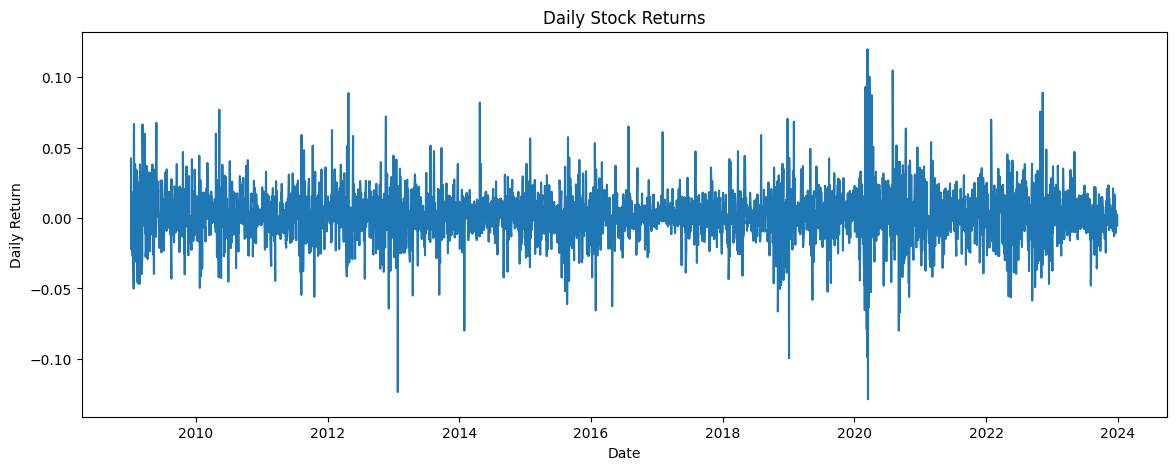

In [50]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Daily_Return"])

plt.title("Daily Stock Returns")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.show()

This visualization shows the daily percentage changes in the stock’s closing price over time. Daily returns help measure short-term stock performance and provide insight into market volatility and price fluctuations.

Key Findings
The daily returns fluctuated around zero throughout the observed period, indicating regular day-to-day changes in stock prices.
Most return values remained within a relatively moderate range, suggesting that extreme price changes were less frequent.
Several sharp positive and negative spikes can be observed, particularly around 2020 and later years, indicating periods of increased market volatility.
The largest fluctuations represent days with unusually strong gains or losses, which may be associated with significant market events or investor reactions.
Volatility appeared to increase in some later periods compared to earlier years, reflecting stronger market movements and changing trading conditions.
Interpretation

The daily return analysis highlights how the stock’s performance changed from one trading day to another. While most daily movements were relatively moderate, occasional large spikes indicate periods of heightened market activity and uncertainty. These fluctuations suggest that the stock experienced both stable periods and periods of stronger volatility over time. Daily return analysis is important for understanding risk, market behavior, and short-term price dynamics.